# PlantVillage — Data Pipeline + ResNet-18 Backbone

## 1. Imports & config

In [6]:
%matplotlib inline
import copy
import json
import random
import time
import zipfile
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.models import resnet18
from huggingface_hub import hf_hub_download
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

REPO_ID = "mohanty/PlantVillage"
CONFIGS = ["color", "grayscale", "segmented"]
IMG_SIZE = 224
VAL_FRACTION = 0.15
BATCH_SIZE = 128
NUM_WORKERS = 0
EPOCHS = 5
LR = 0.05
PRETRAINED = True

CLASS_NAMES = [
    "Apple___Apple_scab", "Apple___Black_rot", "Apple___Cedar_apple_rust", "Apple___healthy",
    "Blueberry___healthy", "Cherry_(including_sour)___Powdery_mildew", "Cherry_(including_sour)___healthy",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot", "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Northern_Leaf_Blight", "Corn_(maize)___healthy", "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)", "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)", "Grape___healthy",
    "Orange___Haunglongbing_(Citrus_greening)", "Peach___Bacterial_spot", "Peach___healthy",
    "Pepper,_bell___Bacterial_spot", "Pepper,_bell___healthy", "Potato___Early_blight",
    "Potato___Late_blight", "Potato___healthy", "Raspberry___healthy", "Soybean___healthy",
    "Squash___Powdery_mildew", "Strawberry___Leaf_scorch", "Strawberry___healthy",
    "Tomato___Bacterial_spot", "Tomato___Early_blight", "Tomato___Late_blight", "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot", "Tomato___Spider_mites Two-spotted_spider_mite", "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus", "Tomato___Tomato_mosaic_virus", "Tomato___healthy",
]
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]


def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    try:
        import torch_directml
        if torch_directml.is_available():
            return torch_directml.device()
    except Exception:
        pass
    return torch.device("cpu")


device = pick_device()
print("device:", device, "| classes:", NUM_CLASSES)

device: cpu | classes: 38


## 2. Download & extract data

In [7]:
DATA_ROOT = Path.home() / ".cache" / "plantvillage"
DATA_ROOT.mkdir(parents=True, exist_ok=True)
extract_dir = DATA_ROOT / "extracted"
done_marker = extract_dir / ".extracted"

zip_path = hf_hub_download(REPO_ID, "data.zip", repo_type="dataset")
print("data.zip:", zip_path)

if not done_marker.exists():
    print("Extracting (~2.2 GB, one-time) ...")
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(extract_dir)
    done_marker.write_text("ok")
    print("done.")
else:
    print("Already extracted.")

IMAGES_BASE = extract_dir
assert (IMAGES_BASE / "raw").is_dir(), f"Expected 'raw/' under {IMAGES_BASE}."
print("images base:", IMAGES_BASE)

data.zip:   0%|          | 0.00/2.18G [00:00<?, ?B/s]

data.zip: /home/hwrd/.cache/huggingface/hub/datasets--mohanty--PlantVillage/snapshots/9e97599868962bd0079b8db4b7f1efa9185fa1e7/data.zip
Extracting (~2.2 GB, one-time) ...
done.
images base: /home/hwrd/.cache/plantvillage/extracted


## 3. Load split lists, leaf map & helpers

In [8]:
split_files = {}
for cfg in CONFIGS:
    for sp in ("train", "test"):
        split_files[(cfg, sp)] = hf_hub_download(REPO_ID, f"splits/{cfg}_{sp}.txt", repo_type="dataset")
leaf_map_path = hf_hub_download(REPO_ID, "leaf_grouping/leaf-map.json", repo_type="dataset")
with open(leaf_map_path, encoding="utf-8") as f:
    LEAF_MAP = json.load(f)


def read_split(cfg, sp):
    with open(split_files[(cfg, sp)], encoding="utf-8") as f:
        return [ln.strip() for ln in f if ln.strip()]


def class_of(rel_path):
    return rel_path.split("/")[2]


def label_of(rel_path):
    return CLASS_TO_IDX[class_of(rel_path)]


def derive_leaf_id(rel_path):
    parts = rel_path.split("/")
    class_name, file_name = parts[2], parts[3]
    ident = file_name.replace("_final_masked", "")
    if "___" in ident:
        ident = ident.split("___")[-1]
    ident = ident.split("copy")[0]
    for ext in (".jpg", ".JPG", ".png", ".PNG"):
        ident = ident.replace(ext, "")
    ident = ident.strip()
    key = ident.lower()
    suggestions = LEAF_MAP.get(key)
    if suggestions:
        if len(suggestions) == 1:
            return suggestions[0]
        for s in suggestions:
            if class_name in s:
                return s
    return f"fallback_{ident}"


for cfg in CONFIGS:
    print(f"{cfg:10s} train={len(read_split(cfg, 'train')):6d}  test={len(read_split(cfg, 'test')):6d}")

color_train.txt:   0%|          | 0.00/4.15M [00:00<?, ?B/s]

color_test.txt:   0%|          | 0.00/1.02M [00:00<?, ?B/s]

grayscale_train.txt:   0%|          | 0.00/4.28M [00:00<?, ?B/s]

grayscale_test.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

segmented_train.txt:   0%|          | 0.00/4.86M [00:00<?, ?B/s]

segmented_test.txt:   0%|          | 0.00/1.28M [00:00<?, ?B/s]

leaf-map.json:   0%|          | 0.00/2.43M [00:00<?, ?B/s]

color      train= 43596  test= 10709
grayscale  train= 43203  test= 11102
segmented  train= 42984  test= 11322


## 4. EDA & class-imbalance audit

In [9]:
color_train = read_split("color", "train")
color_test = read_split("color", "test")
train_labels = np.array([label_of(p) for p in color_train])

cnt_vals = np.array([0] * NUM_CLASSES)
for lab, c in Counter(train_labels.tolist()).items():
    cnt_vals[lab] = c
counts_sorted = sorted(((CLASS_NAMES[i], int(cnt_vals[i])) for i in range(NUM_CLASSES)), key=lambda x: x[1])

print(f"Train images: {len(color_train)} | Test images: {len(color_test)}")
print(f"Largest class: {cnt_vals.max()} | Smallest class: {cnt_vals.min()} | "
      f"Imbalance ratio: {cnt_vals.max() / cnt_vals.min():.1f}x")
print("\n5 rarest classes:")
for name, c in counts_sorted[:5]:
    print(f"  {c:5d}  {name}")
print("5 largest classes:")
for name, c in counts_sorted[-5:]:
    print(f"  {c:5d}  {name}")

Train images: 43596 | Test images: 10709
Largest class: 4527 | Smallest class: 120 | Imbalance ratio: 37.7x

5 rarest classes:
    120  Potato___healthy
    209  Raspberry___healthy
    223  Apple___Cedar_apple_rust
    289  Peach___healthy
    307  Tomato___Tomato_mosaic_virus
5 largest classes:
   1691  Tomato___Bacterial_spot
   1755  Peach___Bacterial_spot
   4117  Soybean___healthy
   4257  Tomato___Tomato_Yellow_Leaf_Curl_Virus
   4527  Orange___Haunglongbing_(Citrus_greening)


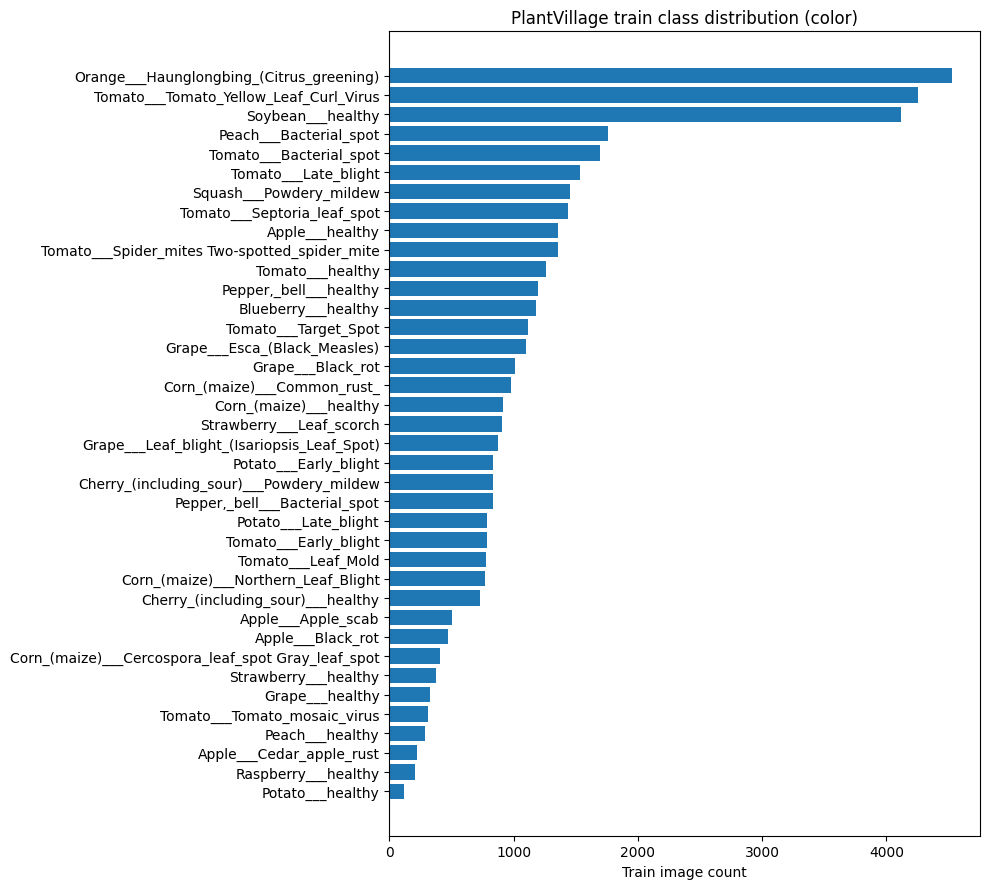

In [10]:
order = np.argsort(cnt_vals)
plt.figure(figsize=(10, 9))
plt.barh([CLASS_NAMES[i] for i in order], cnt_vals[order])
plt.xlabel("Train image count")
plt.title("PlantVillage train class distribution (color)")
plt.tight_layout()
plt.show()

In [11]:
crop_counts = Counter(class_of(p).split("___")[0] for p in color_train)
print("Images per crop (train):")
for crop, c in sorted(crop_counts.items(), key=lambda x: -x[1]):
    print(f"  {c:6d}  {crop}")

Images per crop (train):
   14521  Tomato
    4527  Orange
    4117  Soybean
    3306  Grape
    3058  Corn_(maize)
    2560  Apple
    2044  Peach
    2026  Pepper,_bell
    1744  Potato
    1564  Cherry_(including_sour)
    1457  Squash
    1285  Strawberry
    1178  Blueberry
     209  Raspberry


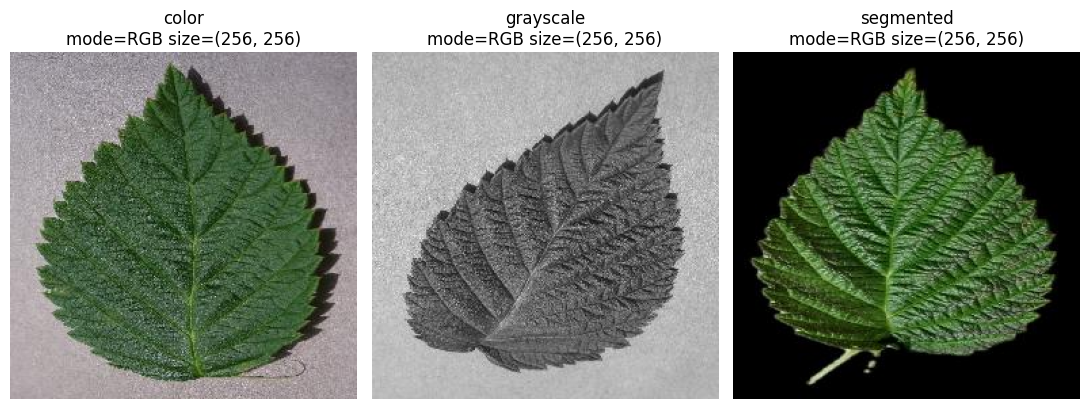

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, cfg in zip(axes, CONFIGS):
    rel = read_split(cfg, "train")[0]
    img = Image.open(IMAGES_BASE / rel)
    ax.imshow(img, cmap="gray" if img.mode == "L" else None)
    ax.set_title(f"{cfg}\nmode={img.mode} size={img.size}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Build train / val / test splits

In [13]:
leaf_ids = np.array([derive_leaf_id(p) for p in color_train])

n_splits = max(2, round(1 / VAL_FRACTION))
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(np.zeros(len(train_labels)), train_labels, groups=leaf_ids))

train_leaf_ids = set(leaf_ids[train_idx].tolist())
val_leaf_ids = set(leaf_ids[val_idx].tolist())

print(f"color train rows: {len(train_idx)} | val rows: {len(val_idx)} "
      f"({len(val_idx) / len(train_labels) * 100:.1f}% of train)")
assert val_leaf_ids.isdisjoint(train_leaf_ids), "leaf overlap between train and val!"
print("No leaf overlap between train and val ✓")

color train rows: 37367 | val rows: 6229 (14.3% of train)
No leaf overlap between train and val ✓


In [14]:
splits = {}
for cfg in CONFIGS:
    files = read_split(cfg, "train")
    lids = np.array([derive_leaf_id(p) for p in files])
    val_mask = np.isin(lids, list(val_leaf_ids))
    splits[cfg] = {
        "train": [f for f, m in zip(files, val_mask) if not m],
        "val": [f for f, m in zip(files, val_mask) if m],
        "test": read_split(cfg, "test"),
    }
    s = splits[cfg]
    print(f"{cfg:10s} train={len(s['train']):6d} val={len(s['val']):6d} test={len(s['test']):6d}")

color      train= 37367 val=  6229 test= 10709
grayscale  train= 38284 val=  4919 test= 11102
segmented  train= 38007 val=  4977 test= 11322


## 6. Imbalance handling — balanced class weights

In [15]:
train_labels_sub = np.array([label_of(p) for p in splits["color"]["train"]])
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.arange(NUM_CLASSES), y=train_labels_sub
)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
print(f"class weight range: {class_weights.min():.3f} - {class_weights.max():.3f}")

class weight range: 0.254 - 9.455


## 7. PyTorch `Dataset`, transforms & `DataLoader`s

In [ ]:
from torchvision.transforms import v2

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),  # Plant leaves should look the same upside-down
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.3, hue=0.05
    ),
    transforms.RandomGrayscale(p=0.05),  # Color-domain shift
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15))
])
eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])


class PlantDataset(Dataset):
    def __init__(self, base, rel_files, tf):
        self.base = Path(base)
        self.files = list(rel_files)
        self.tf = tf

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        rel = self.files[i]
        img = Image.open(self.base / rel).convert("RGB")
        return self.tf(img), CLASS_TO_IDX[class_of(rel)]

In [18]:
ACTIVE_CONFIG = "color"
sp = splits[ACTIVE_CONFIG]
# Combine color and segmented training sets
combined_training_data = splits["color"]["train"] + splits["segmented"]["train"]

train_ds = PlantDataset(IMAGES_BASE, combined_training_data, train_tf)
val_ds = PlantDataset(IMAGES_BASE, sp["val"], eval_tf)
test_ds = PlantDataset(IMAGES_BASE, sp["test"], eval_tf)

pin = device.type == "cuda"
persist = NUM_WORKERS > 0
loader_kw = dict(num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persist)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, **loader_kw)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kw)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kw)
print(f"active config: {ACTIVE_CONFIG} | batch_size={BATCH_SIZE} | num_workers={NUM_WORKERS}")
print(f"batches  train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}")

active config: color | batch_size=128 | num_workers=0
batches  train=589  val=49  test=84


## 8. Model — plug-and-play ResNet-18

In [19]:
def build_model(num_classes=NUM_CLASSES, pretrained=PRETRAINED):
    weights = "IMAGENET1K_V1" if pretrained else None
    m = resnet18(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

model = build_model().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"ResNet-18 | params: {n_params / 1e6:.1f}M | pretrained={PRETRAINED}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/hwrd/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:06<00:00, 7.40MB/s]


ResNet-18 | params: 11.2M | pretrained=True


## 9. Training / evaluation scaffolding

In [20]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

def train_one_epoch(model, loader, optimizer, criterion, device, max_batches=None, log_every=None):
    model.train()
    running, n = 0.0, 0
    for b, (x, y) in enumerate(loader):
        if max_batches is not None and b >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0); n += x.size(0)
        if log_every and (b + 1) % log_every == 0:
            print(f"    batch {b + 1}/{len(loader)}  running_loss {running / n:.4f}", flush=True)
    return running / max(n, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device, max_batches=None):
    model.eval()
    running, n = 0.0, 0
    preds, gts = [], []
    for b, (x, y) in enumerate(loader):
        if max_batches is not None and b >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        out = model(x)
        running += criterion(out, y).item() * x.size(0); n += x.size(0)
        preds.append(out.argmax(1).cpu().numpy())
        gts.append(y.cpu().numpy())
    preds, gts = np.concatenate(preds), np.concatenate(gts)
    return {
        "loss": running / max(n, 1),
        "accuracy": accuracy_score(gts, preds),
        "macro_f1": f1_score(gts, preds, average="macro", zero_division=0),
        "y_true": gts,
        "y_pred": preds,
    }


## 10. Train the baseline (GPU)

In [21]:
baseline = build_model().to(device)
optimizer = torch.optim.SGD(
    baseline.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4, nesterov=True
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

ckpt_dir = Path("outputs"); ckpt_dir.mkdir(exist_ok=True)
ckpt_path = ckpt_dir / f"resnet18_{ACTIVE_CONFIG}_best.pt"

best_f1, best_state, history = -1.0, None, []
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss = train_one_epoch(baseline, train_loader, optimizer, criterion, device, log_every=50)
    scheduler.step()
    val = evaluate(baseline, val_loader, criterion, device)
    history.append((epoch, tr_loss, val["loss"], val["accuracy"], val["macro_f1"]))
    print(f"epoch {epoch:2d}/{EPOCHS} | train_loss {tr_loss:.4f} | "
          f"val_loss {val['loss']:.4f}  acc {val['accuracy']:.4f}  macroF1 {val['macro_f1']:.4f} "
          f"| {time.time() - t0:.0f}s")
    if val["macro_f1"] > best_f1:
        best_f1 = val["macro_f1"]
        best_state = copy.deepcopy(baseline.state_dict())
        torch.save(best_state, ckpt_path)

print(f"\nbest val macro-F1: {best_f1:.4f}  ->  saved to {ckpt_path}")

    batch 50/589  running_loss 4.2423
    batch 100/589  running_loss 3.9564
    batch 150/589  running_loss 3.8002
    batch 200/589  running_loss 3.6722
    batch 250/589  running_loss 3.5607
    batch 300/589  running_loss 3.4556
    batch 350/589  running_loss 3.3487
    batch 400/589  running_loss 3.2511
    batch 450/589  running_loss 3.1594
    batch 500/589  running_loss 3.0778
    batch 550/589  running_loss 3.0011
epoch  1/5 | train_loss 2.9443 | val_loss 1.8928  acc 0.4219  macroF1 0.3288 | 5257s
    batch 50/589  running_loss 2.0277
    batch 100/589  running_loss 1.9797
    batch 150/589  running_loss 1.9177
    batch 200/589  running_loss 1.8623
    batch 250/589  running_loss 1.8129
    batch 300/589  running_loss 1.8164
    batch 350/589  running_loss 1.7904
    batch 400/589  running_loss 1.7504
    batch 450/589  running_loss 1.7086
    batch 500/589  running_loss 1.6675
    batch 550/589  running_loss 1.6334
epoch  2/5 | train_loss 1.6063 | val_loss 1.2099  acc 0.610

TEST  loss 0.2031  accuracy 0.9288  macro_f1 0.9100

Per-class report (precision / recall / F1):
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.92      0.97      0.95       127
                                 Apple___Black_rot       0.94      0.99      0.96       146
                          Apple___Cedar_apple_rust       0.98      1.00      0.99        52
                                   Apple___healthy       0.88      0.84      0.86       286
                               Blueberry___healthy       0.94      0.99      0.97       324
          Cherry_(including_sour)___Powdery_mildew       0.97      0.99      0.98       219
                 Cherry_(including_sour)___healthy       0.88      0.98      0.93       123
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.89      0.82      0.85       107
                       Corn_(maize)___Common_rust_       0.99      0.97   

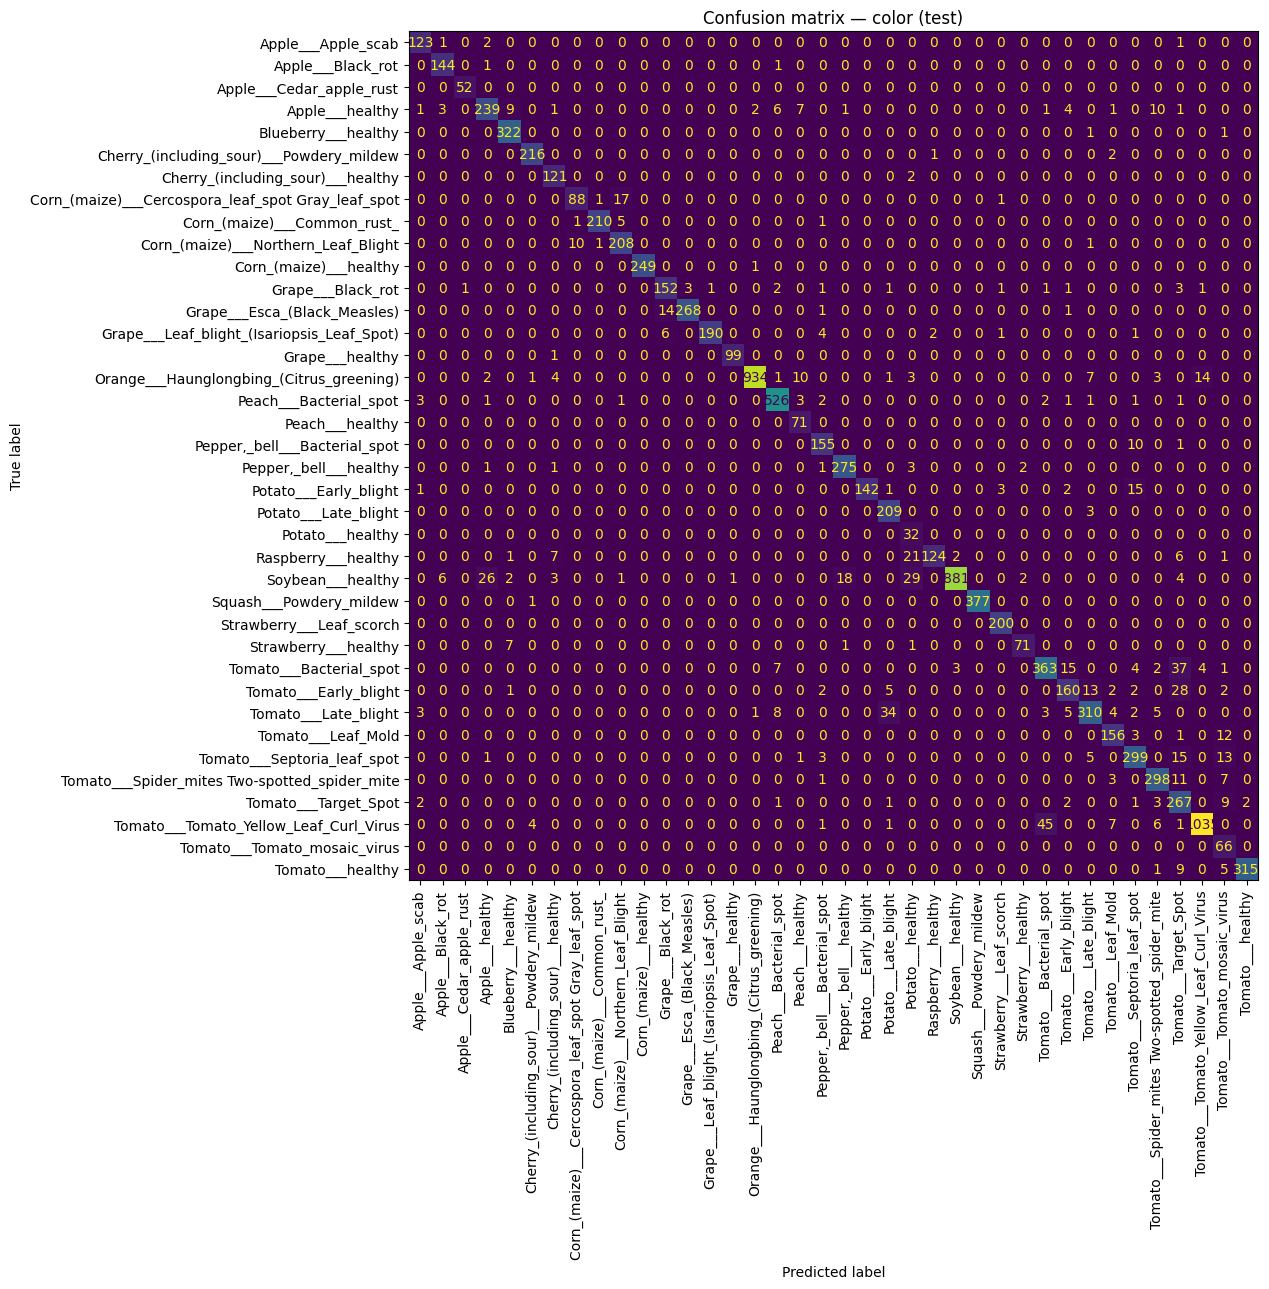

In [22]:
baseline.load_state_dict(best_state)
test = evaluate(baseline, test_loader, criterion, device)
print(f"TEST  loss {test['loss']:.4f}  accuracy {test['accuracy']:.4f}  macro_f1 {test['macro_f1']:.4f}")

print("\nPer-class report (precision / recall / F1):")
print(classification_report(test["y_true"], test["y_pred"],
                            target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(test["y_true"], test["y_pred"])
fig, ax = plt.subplots(figsize=(13, 13))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, xticks_rotation="vertical", colorbar=False)
ax.set_title(f"Confusion matrix — {ACTIVE_CONFIG} (test)")
plt.tight_layout()
plt.show()

## 11. Optimization - Helper Steps

In [32]:
import torch.nn.functional as F

# Mixup/CutMix Augmentation
def mixup_batch(x, y, num_classes, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0))
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# Evaulation - Test-time augmentation
@torch.no_grad()
def evaluate_tta(model, loader, criterion, device, n_aug=5):
    model.eval()
    running, n = 0.0, 0
    preds, gts = [], []

    tta_tf = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(NORM_MEAN, NORM_STD)
    ])

    for b, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)

        probs = torch.zeros(x.size(0), NUM_CLASSES, device=device)
        for _ in range(n_aug):
            probs += torch.softmax(model(x), dim=1)
        probs /= n_aug

        loss = criterion(torch.log(probs), y)  # NLLLoss-style
        running += loss.item() * x.size(0); n += x.size(0)
        preds.append(probs.argmax(1).cpu().numpy())
        gts.append(y.cpu().numpy())
    
    preds, gts = np.concatenate(preds), np.concatenate(gts)
    return {
        "loss": running / max(n, 1),
        "accuracy": accuracy_score(gts, preds),
        "macro_f1": f1_score(gts, preds, average="macro", zero_division=0),
        "y_true": gts,
        "y_pred": preds,
    }

# Focal Loss for Hard Classes (Class Imbalance)
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
    
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

criterion = FocalLoss(weight=class_weights, gamma=2.0)

## 12. Model and Optimizer Setup

In [27]:
def build_model_finetune(num_classes=NUM_CLASSES, pretrained=PRETRAINED):
    weights = "IMAGENET1K_V1" if pretrained else None
    m = resnet18(weights=weights)
    # Freeze layers
    for param in m.parameters():
        param.requires_grad = False
    # Only train new head
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

optimizer = torch.optim.AdamW(
    baseline.parameters(), lr=1e-3, weight_decay=1e-2
)

# Warmup and cosine for pretrained weights
from torch.optim.lr_scheduler import OneCycleLR
scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.1  # 10% warmup
)


## 13. Training Loop For Mixup

In [28]:
def train_one_epoch_mixup(model, loader, optimizer, criterion, device, max_batches=None, log_every=None):
    model.train()
    running, n = 0.0, 0
    for b, (x, y) in enumerate(loader):
        if max_batches is not None and b >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        # Mixup criterion
        x, y_a, y_b, lam = mixup_batch(x, y, NUM_CLASSES)
        loss = mixup_criterion(criterion, model(x), y_a, y_b, lam)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0); n += x.size(0)
        if log_every and (b + 1) % log_every == 0:
            print(f"    batch {b + 1}/{len(loader)}  running_loss {running / n:.4f}", flush=True)
    return running / max(n, 1)

In [ ]:
optimized = build_model_finetune().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

ckpt_dir = Path("outputs"); ckpt_dir.mkdir(exist_ok=True)
ckpt_path = ckpt_dir / f"resnet18_{ACTIVE_CONFIG}_best.pt"

best_f1, best_state, history = -1.0, None, []

# Phase 1: Head only
EPOCHS_P1 = 3
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, optimized.parameters()),
    lr=1e-3
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_P1)

print("Phase 1: Head only")
for epoch in range(1, EPOCHS_P1 + 1):
    t0 = time.time()
    tr_loss = train_one_epoch_mixup(optimized, train_loader, optimizer, criterion, device, log_every=50)
    scheduler.step()
    val = evaluate(optimized, val_loader, criterion, device)
    history.append((epoch, tr_loss, val["loss"], val["accuracy"], val["macro_f1"]))
    print(f"epoch {epoch:2d}/{EPOCHS_P1} | train_loss {tr_loss:.4f} | "
          f"val_loss {val['loss']:.4f}  acc {val['accuracy']:.4f}  macroF1 {val['macro_f1']:.4f} "
          f"| {time.time() - t0:.0f}s")
    if val["macro_f1"] > best_f1:
        best_f1 = val["macro_f1"]
        best_state = copy.deepcopy(optimized.state_dict())
        torch.save(best_state, ckpt_path)

# Phase 2: Unfreeze all
EPOCHS_P2 = 7
for param in optimized.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(optimized.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_P2)

print("Phase 2: Full fine-tune")
for epoch in range(1, EPOCHS_P2 + 1):
    t0 = time.time()
    tr_loss = train_one_epoch_mixup(optimized, train_loader, optimizer, criterion, device, log_every=50)
    scheduler.step()
    val = evaluate(optimized, val_loader, criterion, device)
    history.append((EPOCHS_P1 + epoch, tr_loss, val["loss"], val["accuracy"], val["macro_f1"]))
    print(f"epoch {EPOCHS_P1 + epoch:2d}/{EPOCHS_P1 + EPOCHS_P2} | train_loss {tr_loss:.4f} | "
          f"val_loss {val['loss']:.4f}  acc {val['accuracy']:.4f}  macroF1 {val['macro_f1']:.4f} "
          f"| {time.time() - t0:.0f}s")
    if val["macro_f1"] > best_f1:
        best_f1 = val["macro_f1"]
        best_state = copy.deepcopy(optimized.state_dict())
        torch.save(best_state, ckpt_path)

print(f"\nbest val macro-F1: {best_f1:.4f}  ->  saved to {ckpt_path}")

Phase 1: Head only
    batch 50/589  running_loss 3.7284
    batch 100/589  running_loss 3.4316
    batch 150/589  running_loss 3.2530
    batch 200/589  running_loss 3.0988
    batch 250/589  running_loss 3.0257
    batch 300/589  running_loss 2.9575
    batch 350/589  running_loss 2.9097
    batch 400/589  running_loss 2.8546
    batch 450/589  running_loss 2.8208
    batch 500/589  running_loss 2.7902
    batch 550/589  running_loss 2.7590
epoch  1/3 | train_loss 2.7512 | val_loss 2.5379  acc 0.7653  macroF1 0.7192 | 2476s
    batch 50/589  running_loss 2.5147
    batch 100/589  running_loss 2.4993
    batch 150/589  running_loss 2.4622
    batch 200/589  running_loss 2.4769
    batch 250/589  running_loss 2.4818
    batch 300/589  running_loss 2.4713
    batch 350/589  running_loss 2.4597
    batch 400/589  running_loss 2.4636
    batch 450/589  running_loss 2.4539
    batch 500/589  running_loss 2.4559
    batch 550/589  running_loss 2.4440
epoch  2/3 | train_loss 2.4439 | val_los

AttributeError: module 'torchvision.transforms' has no attribute 'toTensor'

TEST  loss 0.0754  accuracy 0.9841  macro_f1 0.9831

Per-class report (precision / recall / F1):
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.97      0.98       127
                                 Apple___Black_rot       0.92      1.00      0.96       146
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        52
                                   Apple___healthy       0.99      0.99      0.99       286
                               Blueberry___healthy       0.97      1.00      0.99       324
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       219
                 Cherry_(including_sour)___healthy       0.99      1.00      1.00       123
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.93      0.92       107
                       Corn_(maize)___Common_rust_       1.00      0.99   

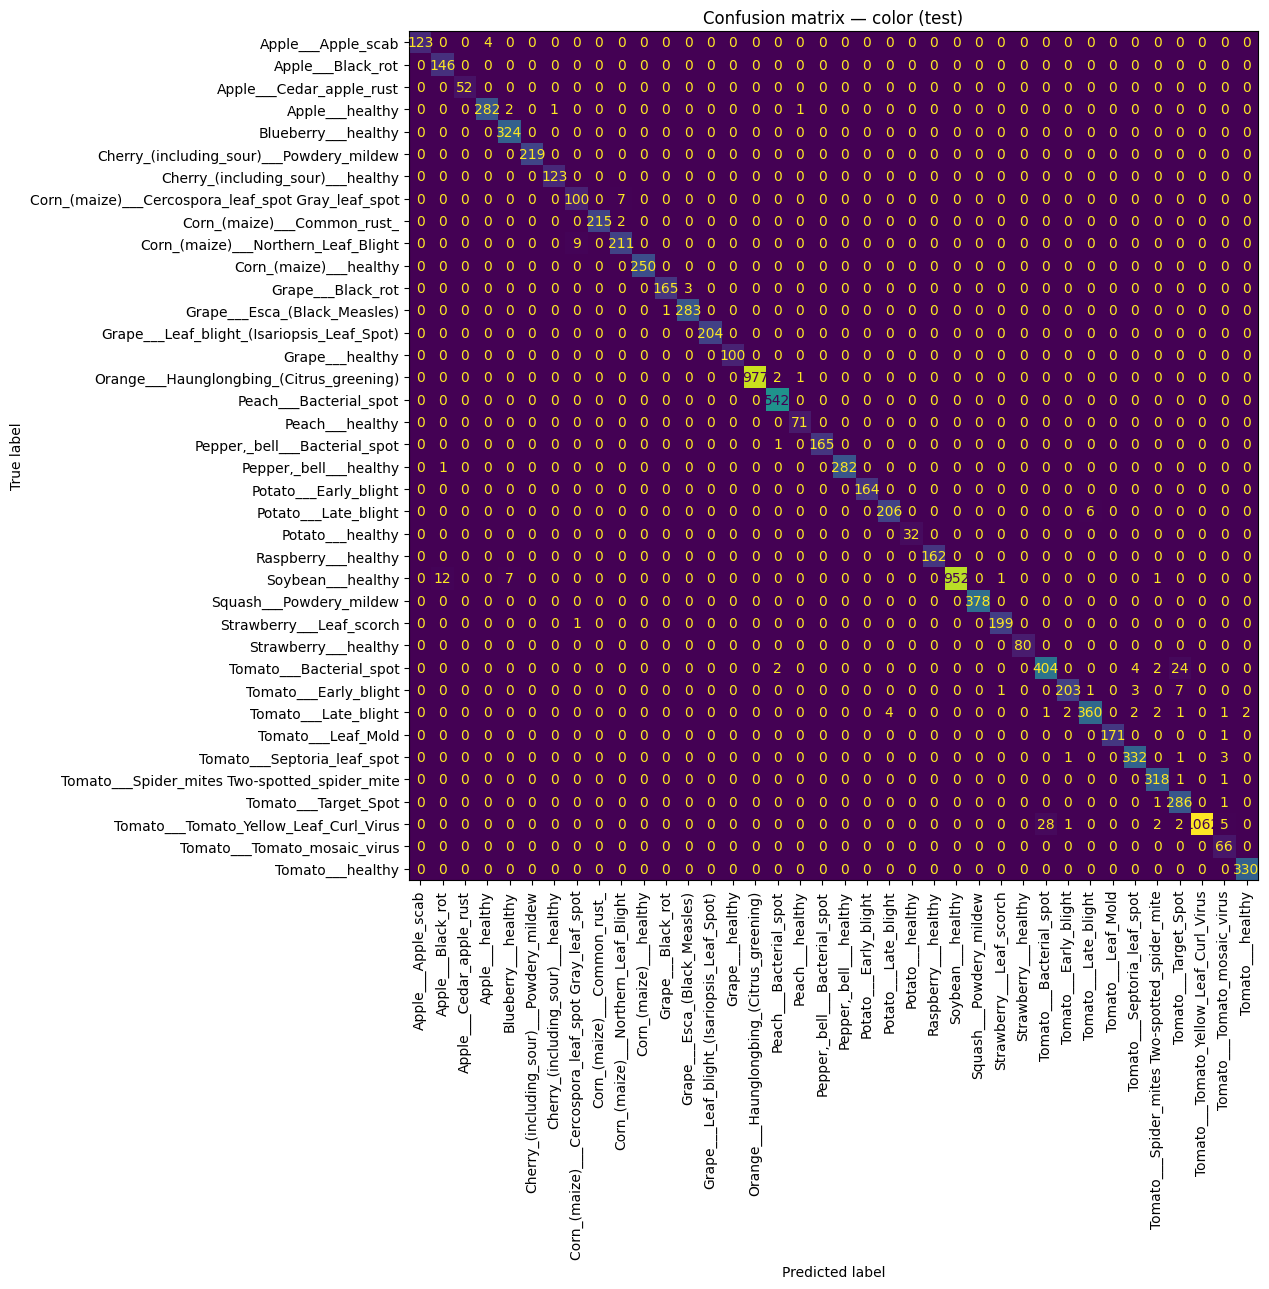

In [33]:
# Ignore the above error, I moved the evaluation code down here after fixing the transforms line
# Final Test Evaluation
optimized.load_state_dict(best_state)
test = evaluate_tta(optimized, test_loader, criterion, device, n_aug=5)
print(f"TEST  loss {test['loss']:.4f}  accuracy {test['accuracy']:.4f}  macro_f1 {test['macro_f1']:.4f}")

print("\nPer-class report (precision / recall / F1):")
print(classification_report(test["y_true"], test["y_pred"],
                            target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(test["y_true"], test["y_pred"])
fig, ax = plt.subplots(figsize=(13, 13))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, xticks_rotation="vertical", colorbar=False
)
ax.set_title(f"Confusion matrix — {ACTIVE_CONFIG} (test)")
plt.tight_layout()
plt.show()

## 14. Summary & next steps